INTELIGÊNCIA ARTIFICIAL APLICADA - MODULO 02

**Professores**: Otávio Calaça Xavier, Sirlon e Alexandre

**Alunos**:
*   Afrain da Silva Calixto
*   Flávio Lourenço da Silva
*   Gustavo Adolpho Souteras Barbosa


O projeto tem como objetivo buscar dados de áudio de pássaros (aqui escolhemos bem-te-vi), que serão usados para classificação. Os dados são obtidos da base Xeno-Canto, que possui ampla variedade de sons de pássaros. Além disto, esta base possui uma API para obtenção de dados que está encapsulado em um objeto que criamos aqui.
Para utilização desta API é necessário uma chave que obtivemos mediante cadastro no site. A chave que vamos usar está disponível no código abaixo:

In [ ]:
API_KEY = "46d81dc362155a1aa1c3cc082b1d9ce0c5cf027a"

Abaixo temos a classe que encapsula a API da Xeno-Canto:

In [ ]:
import requests
import json

class XenoCanto:
    def __init__(self, api_key):
        self.api_key = api_key

    def obter_lista_gravacoes(self, query):


        url = "https://xeno-canto.org/api/3/recordings"
        params = {
            "query": query,
            "key": self.api_key
        }

        response = requests.get(url, params=params)
        response.raise_for_status()
        dados = response.json()

        with open(f"query.json", "w", encoding="utf-8") as f:
            json.dump(dados, f, ensure_ascii=False, indent=4)

        return dados

    def carregar_metadados(self, arquivo_json):
        import os

        if os.path.exists(arquivo_json):
            with open(arquivo_json, "r", encoding="utf-8") as f:
                return json.load(f)

        return None

    def obter_metadados(self, query, arquivo_json):
        dados = self.carregar_metadados(arquivo_json)

        if dados is None:
            dados = self.obter_lista_gravacoes(query)

        return dados

    def baixar_audio(self, gravacao):
        audio = requests.get(gravacao["file"])
        audio.raise_for_status()

        with open(f"{gravacao['id']}.mp3", "wb") as f:
            f.write(audio.content)

Vamos aqui fazer o download de um arquivo de áudio para testar outras funções de processamento de áudio.

In [ ]:
xc = XenoCanto(API_KEY)
dados = xc.obter_metadados('sp:"Pitangus sulphuratus"', "query.json")
print(f"Encontradas {dados['numRecordings']} gravações.")

gravacao = dados["recordings"][0]
audio_url = gravacao["file"]

print(f"ID: {gravacao['id']}")
print(f"Espécie: {gravacao['gen']} {gravacao['sp']}")
print(f"Nome comum: {gravacao['en']}")
print(f"País: {gravacao['cnt']}")
print(f"Qualidade: {gravacao['q']}")
print("Download:", audio_url)

xc.baixar_audio(dados["recordings"][0])

print("Download concluído.")

Encontradas 810 gravações.
ID: 1150325
Espécie: Pitangus sulphuratus
Nome comum: Great Kiskadee
País: French Guiana
Qualidade: A
Download: https://xeno-canto.org/1150325/download
Download concluído.


Temos agora o arquivo de som desejado. Podemos fazer vários processamentos neste áudio obtido. O primeiro passo é instalar as bibliotecas necessárias para este processamento.

In [ ]:
!pip install -q librosa soundfile pyarrow

In [ ]:
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import librosa
import librosa.display

In [ ]:
filename = f"{gravacao['id']}.mp3"
som, sr = librosa.load(filename, sr=None)

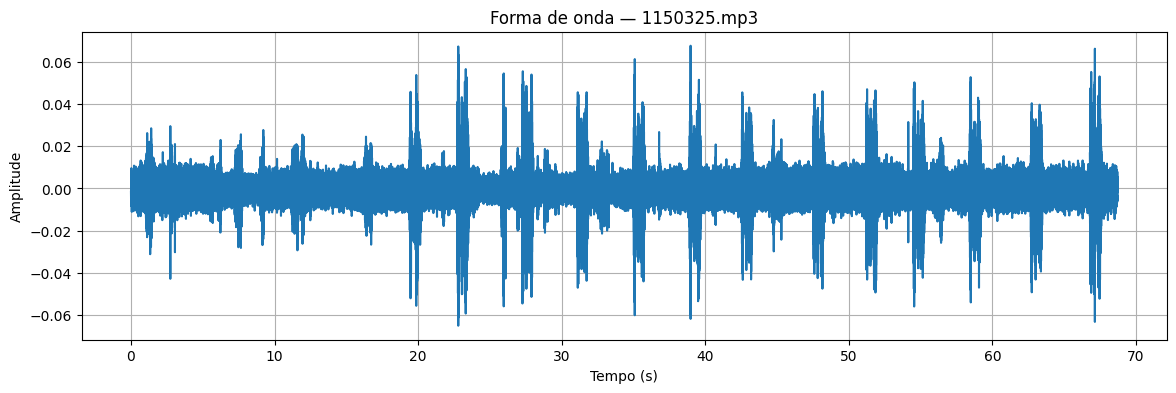

In [ ]:
# Cria o eixo do tempo em segundos.
time = np.arange(len(som)) / sr

plt.figure(figsize=(14, 4))

plt.plot(time, som)

plt.title(f"Forma de onda — {filename}")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.show()

Estou copiando aqui a função criada pelo professor, pois ela extrai muitas características interessantes.

In [ ]:
def extract_audio_features(file_path: Path) -> dict:
    """
    Extrai atributos sonoros simples de um arquivo de áudio.

    Esses atributos podem ser usados posteriormente em:
    - análise exploratória;
    - dashboards;
    - classificação de sons;
    - detecção de anomalias;
    - modelos de Aprendizagem de Máquina.
    """
    signal, sr = librosa.load(file_path, sr=None)

    duration_seconds = librosa.get_duration(
        y=signal,
        sr=sr
    )

    # Energia média do sinal.
    # Valores maiores indicam sinais mais intensos.
    energy_mean = float(np.mean(signal ** 2))

    # RMS representa a magnitude média do sinal.
    # É uma medida comum de intensidade sonora.
    rms = librosa.feature.rms(y=signal)
    rms_mean = float(np.mean(rms))
    rms_std = float(np.std(rms))

    # Zero Crossing Rate mede quantas vezes o sinal cruza o zero.
    # Sons mais agudos ou ruidosos tendem a ter valores maiores.
    zcr = librosa.feature.zero_crossing_rate(y=signal)
    zcr_mean = float(np.mean(zcr))
    zcr_std = float(np.std(zcr))

    # Spectral Centroid indica onde está o "centro de massa" do espectro.
    # Em geral, sons mais agudos têm centroides maiores.
    spectral_centroid = librosa.feature.spectral_centroid(
        y=signal,
        sr=sr
    )
    spectral_centroid_mean = float(np.mean(spectral_centroid))

    # Spectral Bandwidth mede a dispersão das frequências ao redor do centroide.
    spectral_bandwidth = librosa.feature.spectral_bandwidth(
        y=signal,
        sr=sr
    )
    spectral_bandwidth_mean = float(np.mean(spectral_bandwidth))

    # MFCCs são atributos muito usados em tarefas de áudio e fala.
    # Aqui extraímos 5 coeficientes médios para manter a demonstração simples.
    mfcc = librosa.feature.mfcc(
        y=signal,
        sr=sr,
        n_mfcc=5
    )

    mfcc_means = np.mean(mfcc, axis=1)

    return {
        "audio_id": file_path,
        "duration_seconds": float(duration_seconds),
        "energy_mean": energy_mean,
        "rms_mean": rms_mean,
        "rms_std": rms_std,
        "zcr_mean": zcr_mean,
        "zcr_std": zcr_std,
        "spectral_centroid_mean": spectral_centroid_mean,
        "spectral_bandwidth_mean": spectral_bandwidth_mean,
        "mfcc_1_mean": float(mfcc_means[0]),
        "mfcc_2_mean": float(mfcc_means[1]),
        "mfcc_3_mean": float(mfcc_means[2]),
        "mfcc_4_mean": float(mfcc_means[3]),
        "mfcc_5_mean": float(mfcc_means[4]),
        "features_extracted_at": datetime.now().isoformat(timespec="seconds")
    }

Vamos usar esta função no nosso arquivo de áudio...

In [ ]:
extract_audio_features(filename)

{'audio_id': '1150325.mp3',
 'duration_seconds': 68.70532879818595,
 'energy_mean': 2.604962355690077e-05,
 'rms_mean': 0.004119584336876869,
 'rms_std': 0.0030127218924462795,
 'zcr_mean': 0.19283000485806015,
 'zcr_std': 0.04640469159031768,
 'spectral_centroid_mean': 5348.969541938466,
 'spectral_bandwidth_mean': 4614.232983812181,
 'mfcc_1_mean': -456.2173767089844,
 'mfcc_2_mean': 80.77149963378906,
 'mfcc_3_mean': -8.37675666809082,
 'mfcc_4_mean': 49.28814697265625,
 'mfcc_5_mean': 2.638352870941162,
 'features_extracted_at': '2026-07-08T01:19:50'}

Vou agora extrair os MFCCs (Mel-frequency cepstral coefficients) deste sinal de áudio. A biblioteca Librosa divide o áudio em janelas, aplica uma janela matemática (por padrão, uma janela de Hann) para reduzir descontinuidades nas bordas, calcula a FFT de cada janela e gera os MFCCs. O parâmetro *n_mfcc* indica quantos MFCCs deseja-se gerar. O retorno da função é uma matriz bidimensional com *n_mfcc* número de linhas, uma para cada coeficiente, e *n* número de colunas, que vai indicar quantas janelas foram analizadas.

In [ ]:
quantidade_coeficientes = 20

In [ ]:
mfcc = librosa.feature.mfcc(
    y=som,
    sr=sr,
    n_mfcc=quantidade_coeficientes
)

print(mfcc.shape)

(20, 5918)


In [ ]:
mfcc

array([[-4.96584473e+02, -4.65639130e+02, -4.64965820e+02, ...,
        -4.66062073e+02, -4.69334229e+02, -4.69150055e+02],
       [ 9.17685928e+01,  9.18330765e+01,  9.08313751e+01, ...,
         1.04798355e+02,  9.76587219e+01,  8.75345612e+01],
       [ 5.71434784e+00,  6.15527391e+00,  1.05512323e+01, ...,
         7.55064487e+00,  7.00428009e+00, -3.64354277e+00],
       ...,
       [-3.81054688e+00,  1.25856996e-01, -3.34250116e+00, ...,
         2.22609901e+00,  3.02247238e+00,  2.76336169e+00],
       [-4.13947058e+00,  6.08122706e-01,  1.23597407e+00, ...,
        -5.22633743e+00, -2.15345526e+00,  4.26396084e+00],
       [-5.88851404e+00, -3.03972149e+00, -2.89757466e+00, ...,
        -4.24224228e-01, -1.11182022e+00,  1.47981286e-01]], dtype=float32)

Vamos aqui visualizar este espectograma.

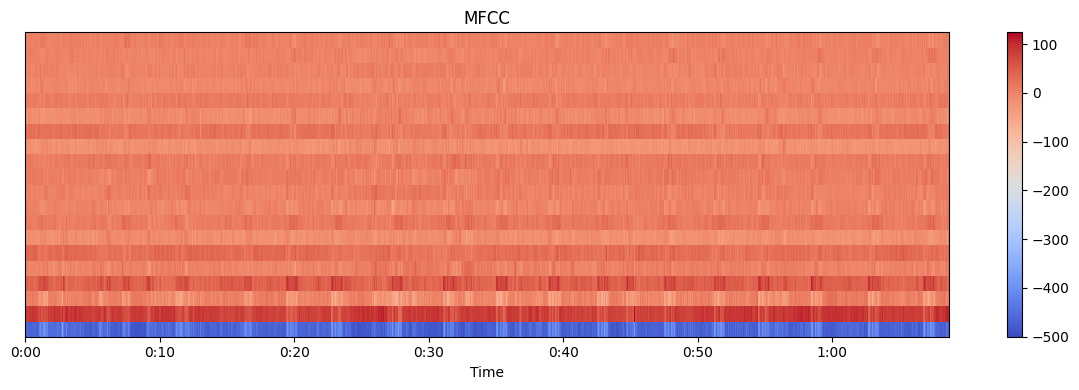

In [ ]:
plt.figure(figsize=(12,4))

librosa.display.specshow(
    mfcc,
    x_axis='time',
    sr=sr
)

plt.colorbar()
plt.title("MFCC")
plt.tight_layout()
plt.show()

Precisamos agora deixar o arquivo de áudio em um formato padronizado para ser usado no treinamento de redes neurais artificiais. Como a duração do áudio vai gerar um número de janelas variável, uma das soluções possíveis é calcular a média de todas as janelas, obtendo-se assim uma matriz de *n_mfcc* linhas e uma coluna. Para uma melhor abordagem, pode-se ainda adicionar o desvio padrão e criar um vetor de 2 * *n_mfcc* valores.

In [ ]:
mfcc_media = np.mean(mfcc, axis=1)
mfcc_desvio = np.std(mfcc, axis=1)

caracteristicas = np.concatenate((mfcc_media, mfcc_desvio))
print(caracteristicas.shape)

(40,)


In [ ]:
caracteristicas

array([-4.5621738e+02,  8.0771500e+01, -8.3767567e+00,  4.9288147e+01,
        2.6383529e+00,  2.7625740e+01, -1.5424599e+01,  1.4060700e+01,
       -2.8251216e+00,  4.1645842e+00,  7.4952869e+00,  1.1644497e+01,
       -1.8868000e+01,  1.8077192e+01, -8.7803268e+00,  8.1355190e+00,
       -5.6445127e+00,  2.2099207e-01,  1.1220351e+00,  2.0567064e+00,
        2.4062910e+01,  1.4006222e+01,  2.0132721e+01,  1.5700174e+01,
        9.9866695e+00,  9.2123318e+00,  8.3141413e+00,  9.8563414e+00,
        9.6677513e+00,  9.0606604e+00,  8.8359261e+00,  8.2010717e+00,
        7.7953300e+00,  9.5039454e+00,  9.0979815e+00,  7.3308592e+00,
        6.9373059e+00,  6.7458496e+00,  6.7405405e+00,  6.9642663e+00],
      dtype=float32)

Estou criando aqui uma classe para organizar a Padronização dos dados. O objetivo é que ela fique parecida com a classe existente em bibliotecas padrão, para depois haver uma comparação.
Tenho que fazer uma observação aqui. Esta Padronização é diferente da Normalização que nos foi ensinada. A Padronização deixa os dados com média 0 e desvio padrão 1. A normalização faz os dados variarem de 1 a -1. Eu ainda tenho que olhar as diferenças dos dois e porque me foi recomendado usar a Padronização neste caso (para usar em KNN), então vou deixar esta função como está até entender esta parte.

In [ ]:
class MeuStandardScaler:
  def fit(self, X):
    self.media = np.mean(X, axis=0)
    self.desvio = np.std(X, axis=0)

  def transform(self, X):
    return (X - self.media) / self.desvio

  def fit_transform(self, X):
    self.fit(X)
    return self.transform(X)

Aqui vou fazer um pequeno teste nesta classe para ver como ficam os dados depois da Padronização.

In [ ]:
scaler = MeuStandardScaler()

caracteristicas = scaler.fit_transform(caracteristicas)
caracteristicas

array([-6.0987735 ,  1.1116431 , -0.08539478,  0.68890053,  0.06251056,
        0.3980286 , -0.18002966,  0.2158841 , -0.01085022,  0.08300404,
        0.12772703,  0.18344054, -0.22626592,  0.26981553, -0.09081371,
        0.13632375, -0.04870758,  0.03005146,  0.04215022,  0.05470052,
        0.35018873,  0.21515258,  0.29741612,  0.23789813,  0.16118006,
        0.15078264,  0.1387222 ,  0.15943009,  0.1568978 ,  0.14874609,
        0.14572847,  0.13720396,  0.13175586,  0.1546983 ,  0.14924721,
        0.12551919,  0.12023474,  0.11766397,  0.11759268,  0.12059675],
      dtype=float32)

Inicio da implementação do Multilayer Perceptron (Perceptron de Múltiplas Camadas)





 Arquitetura da rede

  Camada de entrada: 40

  Neurônios camada oculta 1: 64

  Neurônios camada oculta 2: 64

  Função de ativação: ReLU

  Função de perda:

In [ ]:
import numpy as np

Entradas = np.array([[]])


class Perceptron:
  def __init__(self, entradas, neuronios_camadas_ocultas, seed=42):
    self.entradas = np.array(entradas, dtype=float)
    self.neuronios_camadas_ocultas = np.array(neuronios_camadas_ocultas, dtype=int)
    self.seed = seed
    self.pesos = []
    self.biases = []

    """
        Parâmetros:
            entradas:
                Exemplo: [[0,123545, 1,254872, 1,254875, 0,154784, ...],
                          [0,123545, 1,254872, 1,254875, 0,154784, ...],
                          [0,123545, 1,254872, 1,254875, 0,154784, ...],
                          [0,123545, 1,254872, 1,254875, 0,154784, ...]]

            neuronios_camadas_ocultas:
                Quantidade de neurônios em cada camada oculta.
                Exemplo: [10, 8, 6] -> Camada 1 com 10 neurônios
                                    -> Camada 2 com 08 neurônios
                                    -> Camada 3 com 06 neurônios

            seed:
                Valor usado para tornar a inicialização reproduzível.
    """

    self.inicializar_pesos()

  def inicializar_pesos(self):
    """
    Inicializa os pesos e biases
    """
    if self.entradas.ndim != 2:
      raise ValueError(
          "As entradas devem ser um array bidimensional, "
          "por exemplo: [[0.515, 0.812, 0.287], [0.474, 0.745, 0.158]]"
      )

    if self.neuronios_camadas_ocultas.ndim != 1:
      raise ValueError(
          "O(s) neurônio(s) da(s) camada(s) oculta(s) devem ser um array,"
          "unidimensional, por exemplo: [10, 8, 6, ...]"
      )

    "TODO: validação para informar ao menos uma camada oculta"
    "TODO: validação para quantidade de neurônios maior que 0"

    gerador = np.random.default_rng(seed=42)

    quantidade_entradas_camada = len(Entradas)



